タイタニック号の生存率/死亡率に性差（男女差）があるか？

このプログラムを動作させる前に、男性の生存率と女性の生存率を計算してみてください。excelを使えば簡単にできます。


比率の差の有無が実際にあるか否かを検定で示す。

z検定を使って調べるプログラム

以下のページにZ検定がわかりやすく説明されています。
https://bellcurve.jp/statistics/course/18227.html

In [1]:
import os

# ローカルパスの設定
raw_dir     = '../data/raw/'
split_dir   = '../data/split_from_train/'
missing_dir = '../data/missing_store/'

os.makedirs(split_dir,   exist_ok=True)
os.makedirs(missing_dir, exist_ok=True)

print("パス設定完了")


パス設定完了


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

titanic dataを読み込む

In [3]:
#
# 学習データの読み込み (data/raw/train.csv)
#
train_df = pd.read_csv(raw_dir + 'train.csv')

#
# データフレームの大きさを確認しておく
#
print(train_df.shape)

#
# 学習データの先頭5行を確認する。
#
train_df.head()


(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


生存者分析：性差の有無を確認する

In [4]:
#
# 男性の生存データを作成する
#
male_survived = train_df.loc[train_df['Sex'] == 'male', 'Survived'].values

#
# 女性の生存データを作成する
#
female_survived = train_df.loc[train_df['Sex'] == 'female', 'Survived'].values

比率の差の検定を行う（z検定）

In [5]:
import numpy as np
import statsmodels.api as sm

#
# サンプルデータ
# 0: 死亡, 1: 生存
#
# male_labels = np.array([0, 1, 0, 1, 0, 1, 1, 0, 1, 1])
# female_labels = np.array([1, 1, 1, 0, 0, 1, 1, 1, 0, 1])
male_labels = male_survived
female_labels = female_survived


#
# 各グループの死亡者数と試行回数（全体数）を計算
#
male_deaths = np.sum(male_labels == 0)
female_deaths = np.sum(female_labels == 0)
male_total = len(male_labels)
female_total = len(female_labels)

#
# 成功数（死亡者数）と試行回数（全体数）を配列にまとめる
#
successes = np.array([male_deaths, female_deaths])
totals = np.array([male_total, female_total])

#
# 比率の差の検定の実行
#
stat, p_value = sm.stats.proportions_ztest(successes, totals)

print(f"Z統計量: {stat}")
print(f"p値: {p_value}")

#
# 結果の解釈
#
alpha = 0.05
if p_value < alpha:
    print("男女の死亡率に有意な差があります。")
else:
    print("男女の死亡率に有意な差はありません。")

Z統計量: 16.218833930670097
p値: 3.7117477701134797e-59
男女の死亡率に有意な差があります。


## 特徴量ごとの生存率・分布の可視化

READMEで挙げられた各特徴量（Pclass, Sex, Age, SibSp, Parch, Fare, Embarked）について、
生存（Survived=1）と死亡（Survived=0）の分布を確認する。


/tmp/ipykernel_682860/3767402431.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_pclass, labels=['クラス1', 'クラス2', 'クラス3'],


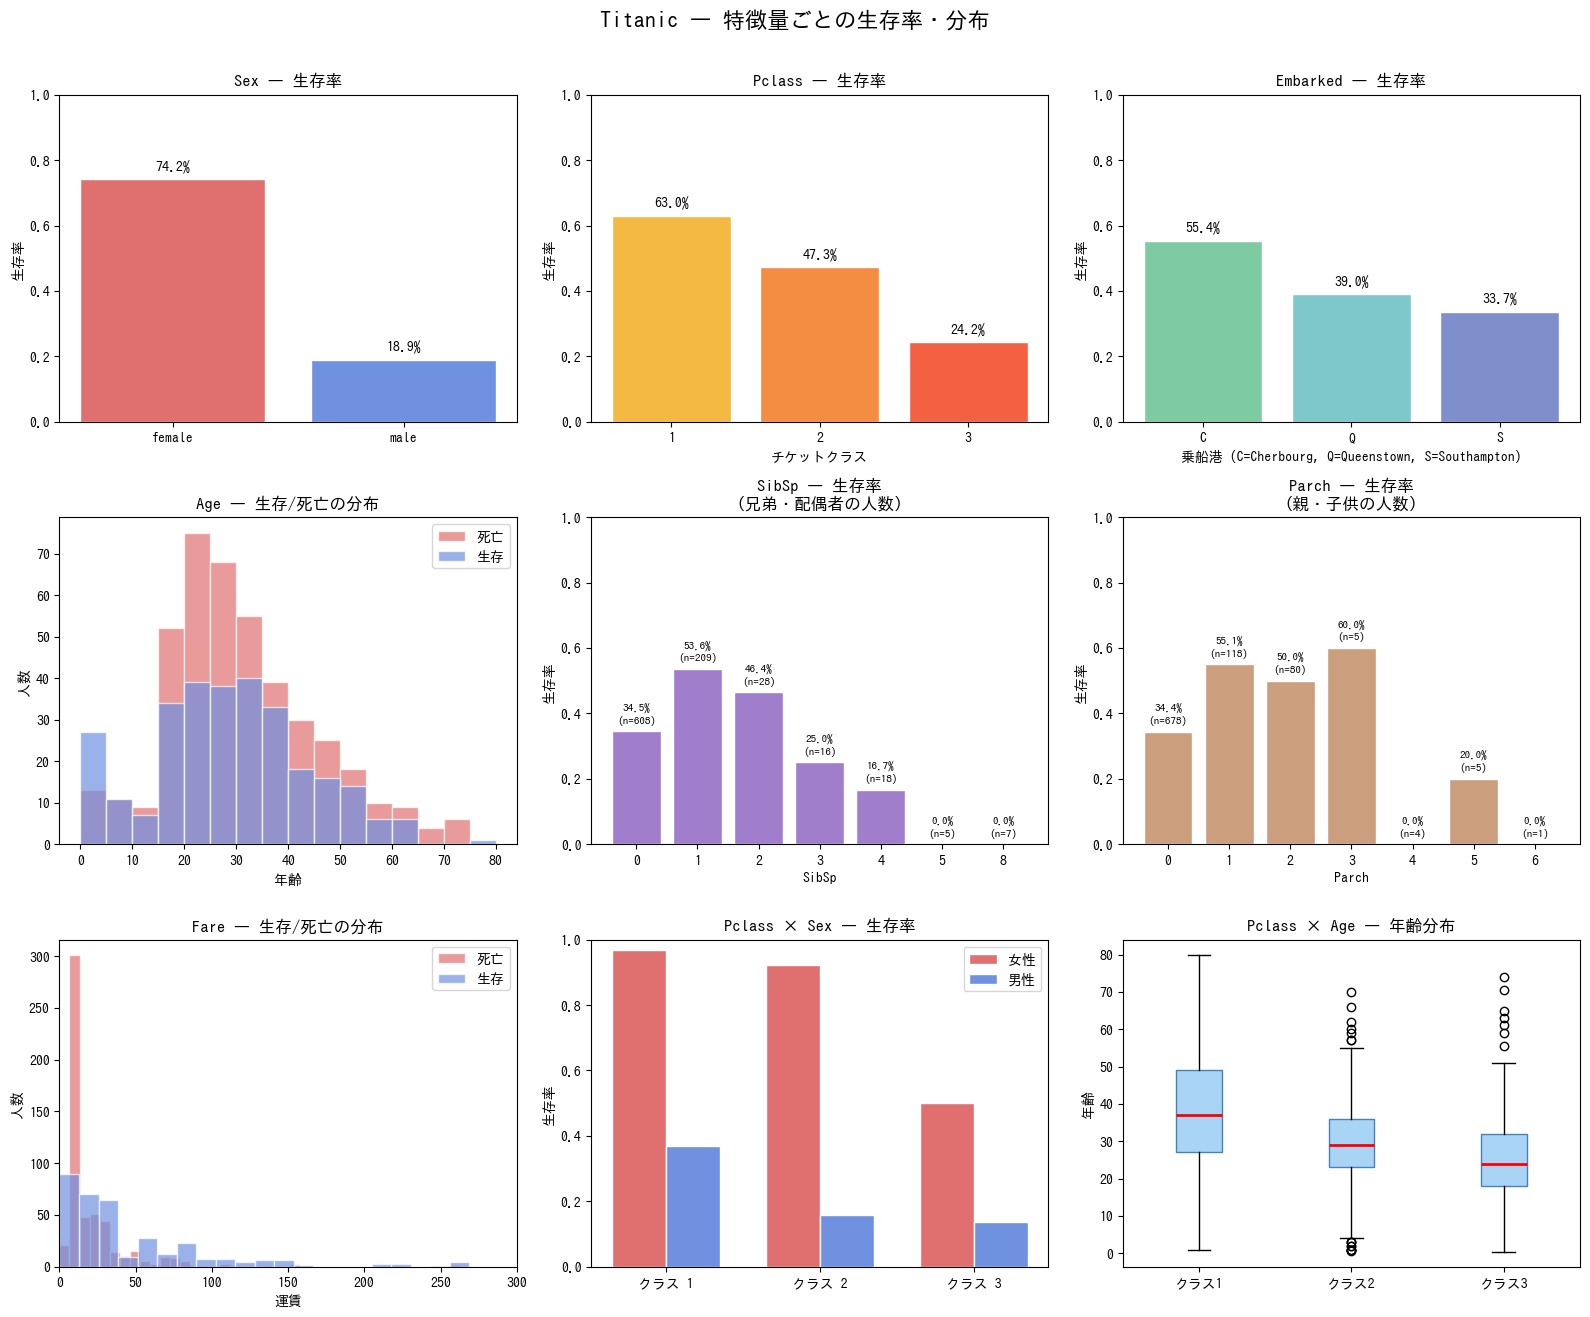

グラフを data/feature_survival_analysis.png に保存しました


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import numpy as np

# 日本語フォントの設定（IPAGothic）
plt.rcParams['font.family'] = 'IPAGothic'
plt.rcParams['axes.unicode_minus'] = False  # マイナス記号の文字化け防止

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle('Titanic — 特徴量ごとの生存率・分布', fontsize=16, fontweight='bold', y=1.01)

survived     = train_df[train_df['Survived'] == 1]
not_survived = train_df[train_df['Survived'] == 0]

# ─── 1. Sex ───────────────────────────────────────────────
ax = axes[0, 0]
sex_survival = train_df.groupby('Sex')['Survived'].mean()
bars = ax.bar(sex_survival.index, sex_survival.values,
              color=['#e07070', '#7090e0'], edgecolor='white')
ax.set_title('Sex — 生存率')
ax.set_ylabel('生存率')
ax.set_ylim(0, 1)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02,
            f'{b.get_height():.1%}', ha='center', va='bottom', fontsize=10)

# ─── 2. Pclass ────────────────────────────────────────────
ax = axes[0, 1]
pclass_survival = train_df.groupby('Pclass')['Survived'].mean()
bars = ax.bar(pclass_survival.index.astype(str), pclass_survival.values,
              color=['#f4b942', '#f48c42', '#f46042'], edgecolor='white')
ax.set_title('Pclass — 生存率')
ax.set_ylabel('生存率')
ax.set_ylim(0, 1)
ax.set_xlabel('チケットクラス')
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02,
            f'{b.get_height():.1%}', ha='center', va='bottom', fontsize=10)

# ─── 3. Embarked ──────────────────────────────────────────
ax = axes[0, 2]
emb_survival = train_df.groupby('Embarked')['Survived'].mean()
bars = ax.bar(emb_survival.index, emb_survival.values,
              color=['#7ecba1', '#7ec8cb', '#7e8fcb'], edgecolor='white')
ax.set_title('Embarked — 生存率')
ax.set_ylabel('生存率')
ax.set_ylim(0, 1)
ax.set_xlabel('乗船港 (C=Cherbourg, Q=Queenstown, S=Southampton)')
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02,
            f'{b.get_height():.1%}', ha='center', va='bottom', fontsize=10)

# ─── 4. Age — 分布ヒストグラム ────────────────────────────
ax = axes[1, 0]
bins = range(0, 85, 5)
ax.hist(not_survived['Age'].dropna(), bins=bins, alpha=0.7,
        color='#e07070', label='死亡', edgecolor='white')
ax.hist(survived['Age'].dropna(), bins=bins, alpha=0.7,
        color='#7090e0', label='生存', edgecolor='white')
ax.set_title('Age — 生存/死亡の分布')
ax.set_xlabel('年齢')
ax.set_ylabel('人数')
ax.legend()

# ─── 5. SibSp ─────────────────────────────────────────────
ax = axes[1, 1]
sibsp_survival = train_df.groupby('SibSp')['Survived'].mean()
sibsp_count    = train_df.groupby('SibSp')['Survived'].count()
bars = ax.bar(sibsp_survival.index.astype(str), sibsp_survival.values,
              color='#a07ecb', edgecolor='white')
ax.set_title('SibSp — 生存率\n(兄弟・配偶者の人数)')
ax.set_ylabel('生存率')
ax.set_ylim(0, 1)
ax.set_xlabel('SibSp')
for b, cnt in zip(bars, sibsp_count.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02,
            f'{b.get_height():.1%}\n(n={cnt})', ha='center', va='bottom', fontsize=8)

# ─── 6. Parch ─────────────────────────────────────────────
ax = axes[1, 2]
parch_survival = train_df.groupby('Parch')['Survived'].mean()
parch_count    = train_df.groupby('Parch')['Survived'].count()
bars = ax.bar(parch_survival.index.astype(str), parch_survival.values,
              color='#cb9e7e', edgecolor='white')
ax.set_title('Parch — 生存率\n(親・子供の人数)')
ax.set_ylabel('生存率')
ax.set_ylim(0, 1)
ax.set_xlabel('Parch')
for b, cnt in zip(bars, parch_count.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02,
            f'{b.get_height():.1%}\n(n={cnt})', ha='center', va='bottom', fontsize=8)

# ─── 7. Fare — 分布ヒストグラム ───────────────────────────
ax = axes[2, 0]
ax.hist(not_survived['Fare'].dropna(), bins=40, alpha=0.7,
        color='#e07070', label='死亡', edgecolor='white')
ax.hist(survived['Fare'].dropna(), bins=40, alpha=0.7,
        color='#7090e0', label='生存', edgecolor='white')
ax.set_title('Fare — 生存/死亡の分布')
ax.set_xlabel('運賃')
ax.set_ylabel('人数')
ax.set_xlim(0, 300)
ax.legend()

# ─── 8. Sex × Pclass ──────────────────────────────────────
ax = axes[2, 1]
pivot = train_df.pivot_table('Survived', index='Pclass', columns='Sex', aggfunc='mean')
x = np.arange(len(pivot.index))
w = 0.35
ax.bar(x - w/2, pivot['female'], width=w, label='女性', color='#e07070', edgecolor='white')
ax.bar(x + w/2, pivot['male'],   width=w, label='男性', color='#7090e0', edgecolor='white')
ax.set_title('Pclass × Sex — 生存率')
ax.set_xticks(x)
ax.set_xticklabels([f'クラス {p}' for p in pivot.index])
ax.set_ylabel('生存率')
ax.set_ylim(0, 1)
ax.legend()

# ─── 9. Age × Pclass — ボックスプロット ───────────────────
ax = axes[2, 2]
data_by_pclass = [train_df[train_df['Pclass'] == p]['Age'].dropna().values
                  for p in [1, 2, 3]]
bp = ax.boxplot(data_by_pclass, labels=['クラス1', 'クラス2', 'クラス3'],
                patch_artist=True,
                boxprops=dict(facecolor='#aad4f5', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
ax.set_title('Pclass × Age — 年齢分布')
ax.set_ylabel('年齢')

plt.tight_layout()
plt.savefig('../data/feature_survival_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print("グラフを data/feature_survival_analysis.png に保存しました")


## 図2：生存要因の深掘り分析

- **年齢層別**（子供・青年・成人・高齢）の生存率
- **運賃帯別**（4分位）の生存率  
- **Pclass × Sex ヒートマップ**（交互作用の可視化）
- **敬称（Title）別**生存率（Name列から抽出）
- **家族サイズ**（SibSp + Parch + 1）別生存率
- **単独乗船 vs 家族同伴**の比較


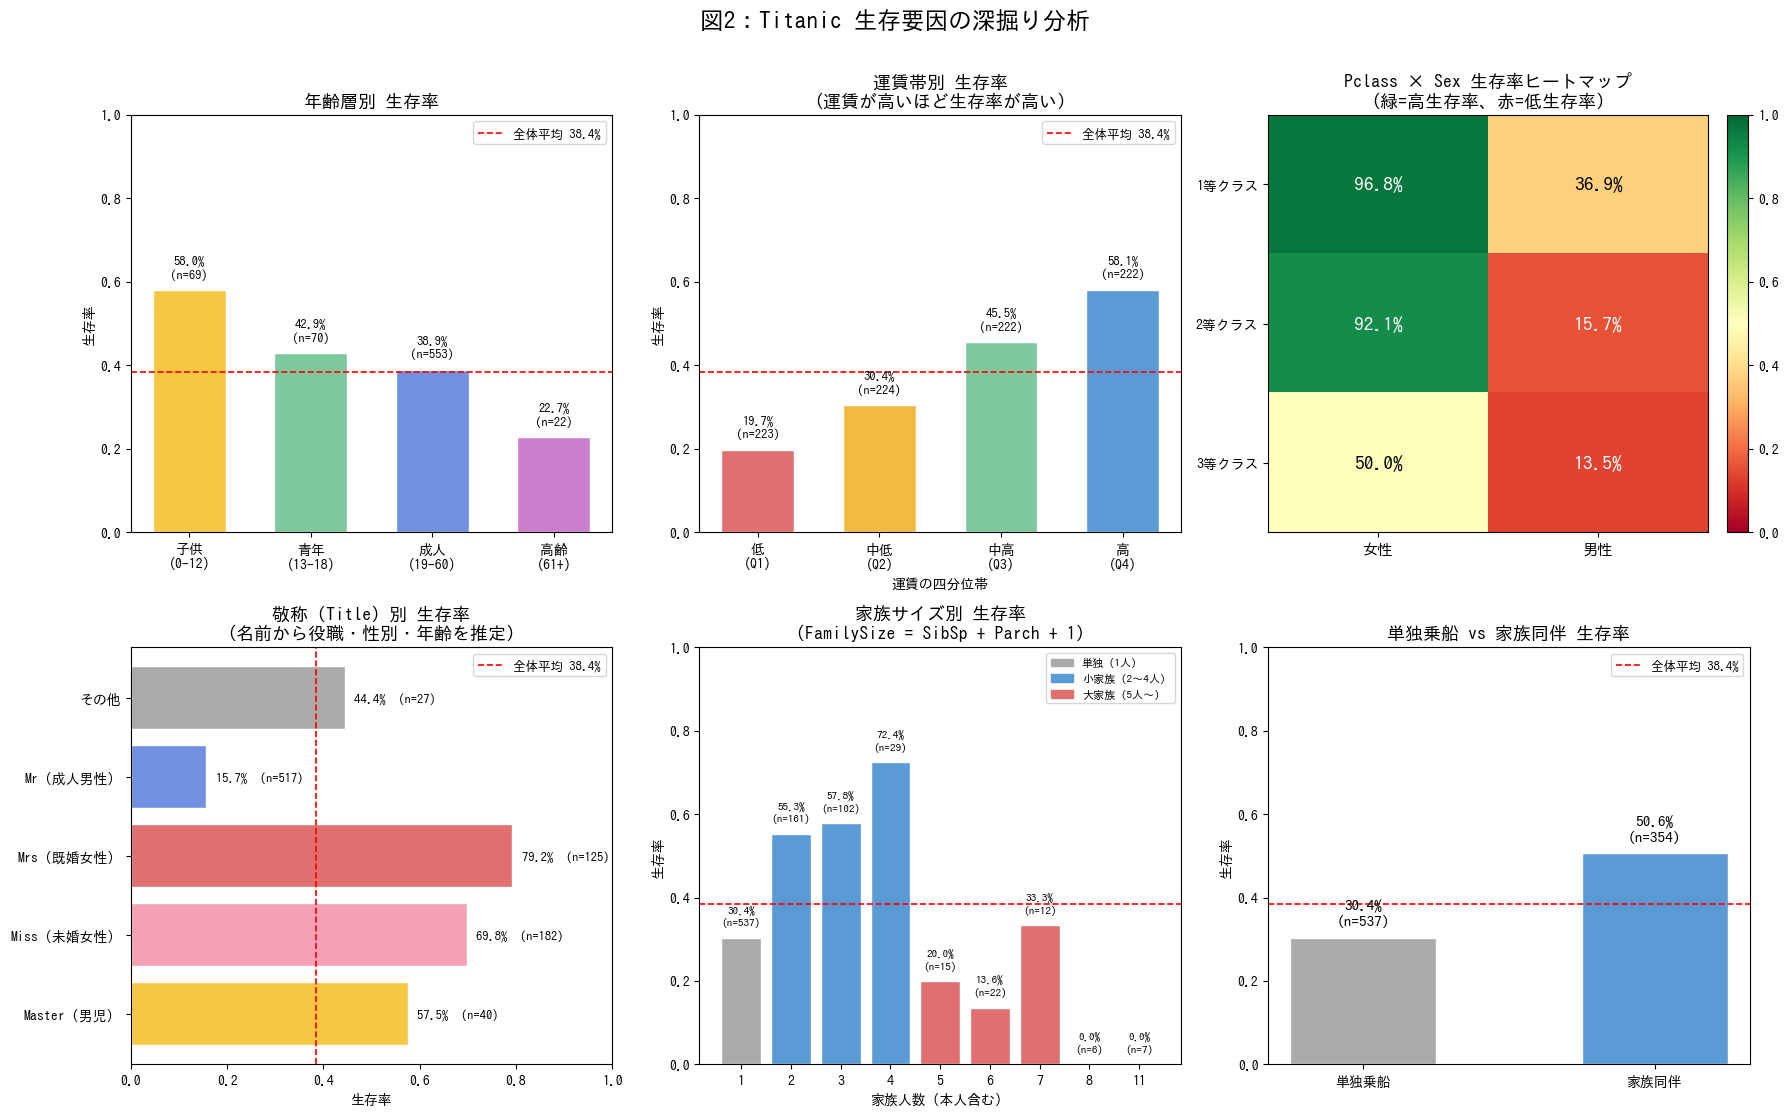

グラフを data/feature_deep_analysis.png に保存しました


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'IPAGothic'
plt.rcParams['axes.unicode_minus'] = False

df = train_df.copy()

# ── 特徴量エンジニアリング ─────────────────────────────────────
# 年齢層
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 60, 100],
                        labels=['子供\n(0-12)', '青年\n(13-18)', '成人\n(19-60)', '高齢\n(61+)'])

# 運賃帯（4分位）
df['FareBand'] = pd.qcut(df['Fare'], 4,
                         labels=['低\n(Q1)', '中低\n(Q2)', '中高\n(Q3)', '高\n(Q4)'])

# 家族サイズ
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).map({True: '単独乗船', False: '家族同伴'})

# 敬称（Title）を Name から抽出
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
title_map = {
    'Mr': 'Mr（成人男性）', 'Miss': 'Miss（未婚女性）',
    'Mrs': 'Mrs（既婚女性）', 'Master': 'Master（男児）',
}
df['TitleGroup'] = df['Title'].map(title_map).fillna('その他')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('図2：Titanic 生存要因の深掘り分析', fontsize=17, fontweight='bold', y=1.01)

COLORS = {'生存': '#5b9bd5', '死亡': '#e07070'}

# ─── 1. 年齢層別 生存率 ────────────────────────────────────
ax = axes[0, 0]
age_surv = df.groupby('AgeGroup', observed=True)['Survived'].agg(['mean', 'count'])
bars = ax.bar(age_surv.index, age_surv['mean'],
              color=['#f4c842', '#7ec8a0', '#7090e0', '#cb7ecb'], edgecolor='white', width=0.6)
ax.set_title('年齢層別 生存率', fontsize=13, fontweight='bold')
ax.set_ylabel('生存率')
ax.set_ylim(0, 1)
ax.axhline(df['Survived'].mean(), color='red', linestyle='--', linewidth=1.2, label=f'全体平均 {df["Survived"].mean():.1%}')
ax.legend(fontsize=9)
for b, (_, row) in zip(bars, age_surv.iterrows()):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.025,
            f'{row["mean"]:.1%}\n(n={int(row["count"])})', ha='center', va='bottom', fontsize=9)

# ─── 2. 運賃帯別 生存率 ────────────────────────────────────
ax = axes[0, 1]
fare_surv = df.groupby('FareBand', observed=True)['Survived'].agg(['mean', 'count'])
bars = ax.bar(fare_surv.index, fare_surv['mean'],
              color=['#e07070', '#f4b942', '#7ec8a0', '#5b9bd5'], edgecolor='white', width=0.6)
ax.set_title('運賃帯別 生存率\n（運賃が高いほど生存率が高い）', fontsize=13, fontweight='bold')
ax.set_ylabel('生存率')
ax.set_ylim(0, 1)
ax.set_xlabel('運賃の四分位帯')
ax.axhline(df['Survived'].mean(), color='red', linestyle='--', linewidth=1.2, label=f'全体平均 {df["Survived"].mean():.1%}')
ax.legend(fontsize=9)
for b, (_, row) in zip(bars, fare_surv.iterrows()):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.025,
            f'{row["mean"]:.1%}\n(n={int(row["count"])})', ha='center', va='bottom', fontsize=9)

# ─── 3. Pclass × Sex ヒートマップ ──────────────────────────
ax = axes[0, 2]
heatmap_data = df.pivot_table('Survived', index='Pclass', columns='Sex', aggfunc='mean')
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks([0, 1])
ax.set_xticklabels(['女性', '男性'], fontsize=11)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels([f'{p}等クラス' for p in heatmap_data.index], fontsize=10)
ax.set_title('Pclass × Sex 生存率ヒートマップ\n（緑=高生存率、赤=低生存率）', fontsize=13, fontweight='bold')
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f'{val:.1%}', ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if val < 0.3 or val > 0.8 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ─── 4. 敬称（Title）別 生存率 ─────────────────────────────
ax = axes[1, 0]
title_order = ['Master（男児）', 'Miss（未婚女性）', 'Mrs（既婚女性）', 'Mr（成人男性）', 'その他']
title_surv = df.groupby('TitleGroup')['Survived'].agg(['mean', 'count']).reindex(title_order).dropna()
colors_t = ['#f4c842', '#f4a0b5', '#e07070', '#7090e0', '#aaaaaa']
bars = ax.barh(title_surv.index, title_surv['mean'], color=colors_t[:len(title_surv)], edgecolor='white')
ax.set_title('敬称（Title）別 生存率\n（名前から役職・性別・年齢を推定）', fontsize=13, fontweight='bold')
ax.set_xlabel('生存率')
ax.set_xlim(0, 1)
ax.axvline(df['Survived'].mean(), color='red', linestyle='--', linewidth=1.2, label=f'全体平均 {df["Survived"].mean():.1%}')
ax.legend(fontsize=9)
for b, (_, row) in zip(bars, title_surv.iterrows()):
    ax.text(b.get_width() + 0.02, b.get_y() + b.get_height()/2,
            f'{row["mean"]:.1%}  (n={int(row["count"])})', va='center', fontsize=9)

# ─── 5. 家族サイズ別 生存率 ────────────────────────────────
ax = axes[1, 1]
fam_surv = df.groupby('FamilySize')['Survived'].agg(['mean', 'count'])
colors_f = ['#aaaaaa' if s == 1 else '#5b9bd5' if s <= 4 else '#e07070'
            for s in fam_surv.index]
bars = ax.bar(fam_surv.index.astype(str), fam_surv['mean'], color=colors_f, edgecolor='white')
ax.set_title('家族サイズ別 生存率\n（FamilySize = SibSp + Parch + 1）', fontsize=13, fontweight='bold')
ax.set_ylabel('生存率')
ax.set_ylim(0, 1)
ax.set_xlabel('家族人数（本人含む）')
ax.axhline(df['Survived'].mean(), color='red', linestyle='--', linewidth=1.2, label=f'全体平均 {df["Survived"].mean():.1%}')
ax.legend(fontsize=9)
patches = [mpatches.Patch(color='#aaaaaa', label='単独（1人）'),
           mpatches.Patch(color='#5b9bd5', label='小家族（2〜4人）'),
           mpatches.Patch(color='#e07070', label='大家族（5人〜）')]
ax.legend(handles=patches, fontsize=8, loc='upper right')
for b, (_, row) in zip(bars, fam_surv.iterrows()):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.025,
            f'{row["mean"]:.1%}\n(n={int(row["count"])})', ha='center', va='bottom', fontsize=8)

# ─── 6. 単独乗船 vs 家族同伴 ───────────────────────────────
ax = axes[1, 2]
alone_surv = df.groupby('IsAlone')['Survived'].agg(['mean', 'count'])
bars = ax.bar(alone_surv.index, alone_surv['mean'],
              color=['#aaaaaa', '#5b9bd5'], edgecolor='white', width=0.5)
ax.set_title('単独乗船 vs 家族同伴 生存率', fontsize=13, fontweight='bold')
ax.set_ylabel('生存率')
ax.set_ylim(0, 1)
ax.axhline(df['Survived'].mean(), color='red', linestyle='--', linewidth=1.2, label=f'全体平均 {df["Survived"].mean():.1%}')
ax.legend(fontsize=9)
for b, (_, row) in zip(bars, alone_surv.iterrows()):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.025,
            f'{row["mean"]:.1%}\n(n={int(row["count"])})', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('../data/feature_deep_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print("グラフを data/feature_deep_analysis.png に保存しました")


## 図3：発表用サマリー — 「何が生存を左右したか」

各要因の生存率差（生存率 − 死亡率）を横棒グラフでランキング表示し、
どの特徴量が最も生存に影響したかを1枚で示す。


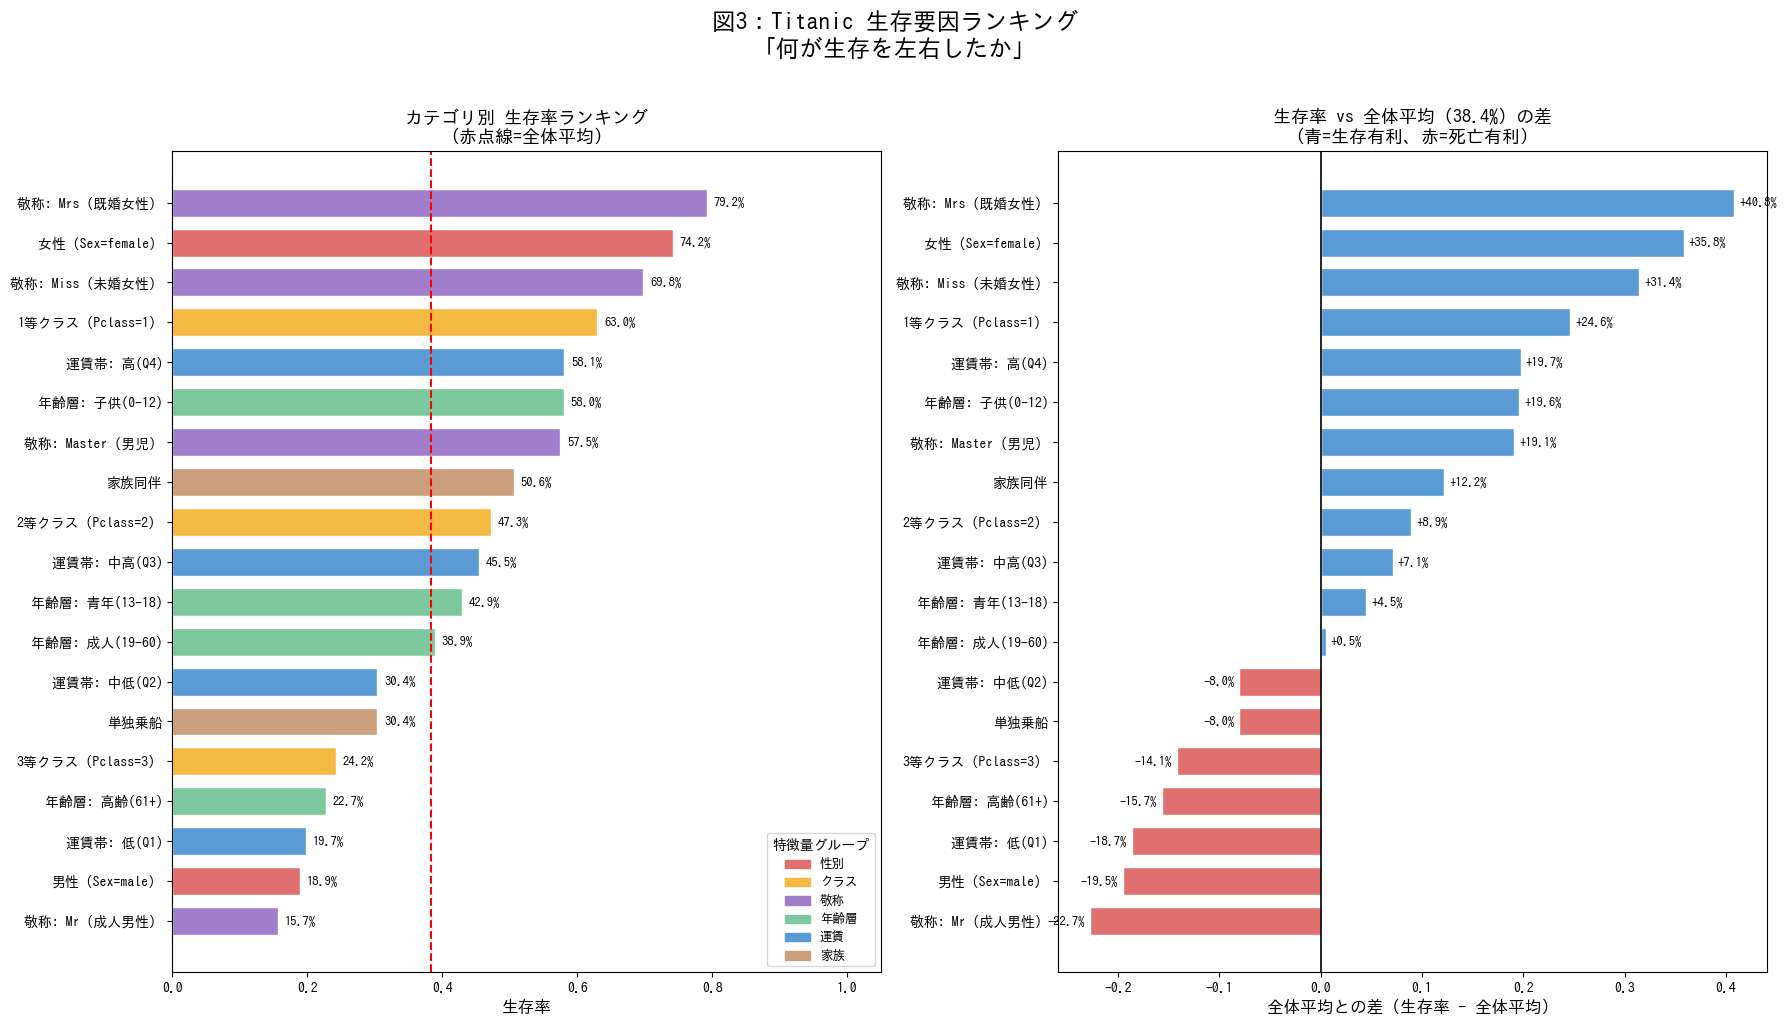

グラフを data/feature_importance_summary.png に保存しました


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'IPAGothic'
plt.rcParams['axes.unicode_minus'] = False

df = train_df.copy()

# ── 特徴量エンジニアリング ─────────────────────────────────────
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
title_map = {'Mr': 'Mr（成人男性）', 'Miss': 'Miss（未婚女性）',
             'Mrs': 'Mrs（既婚女性）', 'Master': 'Master（男児）'}
df['TitleGroup'] = df['Title'].map(title_map).fillna('その他')
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).map({True: '単独乗船', False: '家族同伴'})
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 60, 100],
                        labels=['子供(0-12)', '青年(13-18)', '成人(19-60)', '高齢(61+)'])
df['FareBand'] = pd.qcut(df['Fare'], 4, labels=['低(Q1)', '中低(Q2)', '中高(Q3)', '高(Q4)'])

base_rate = df['Survived'].mean()

# ── 各カテゴリの生存率差を集計 ────────────────────────────────
factors = []
for sex, label in [('female', '女性（Sex=female）'), ('male', '男性（Sex=male）')]:
    rate = df[df['Sex'] == sex]['Survived'].mean()
    factors.append({'label': label, 'rate': rate, 'group': '性別'})

for pc in [1, 2, 3]:
    rate = df[df['Pclass'] == pc]['Survived'].mean()
    factors.append({'label': f'{pc}等クラス（Pclass={pc}）', 'rate': rate, 'group': 'クラス'})

for title in ['Master（男児）', 'Miss（未婚女性）', 'Mrs（既婚女性）', 'Mr（成人男性）']:
    rate = df[df['TitleGroup'] == title]['Survived'].mean()
    factors.append({'label': f'敬称: {title}', 'rate': rate, 'group': '敬称'})

for ag in ['子供(0-12)', '青年(13-18)', '成人(19-60)', '高齢(61+)']:
    subset = df[df['AgeGroup'] == ag]
    if len(subset) > 10:
        factors.append({'label': f'年齢層: {ag}', 'rate': subset['Survived'].mean(), 'group': '年齢層'})

for fb in ['低(Q1)', '中低(Q2)', '中高(Q3)', '高(Q4)']:
    rate = df[df['FareBand'] == fb]['Survived'].mean()
    factors.append({'label': f'運賃帯: {fb}', 'rate': rate, 'group': '運賃'})

for alone, label in [('単独乗船', '単独乗船'), ('家族同伴', '家族同伴')]:
    rate = df[df['IsAlone'] == alone]['Survived'].mean()
    factors.append({'label': label, 'rate': rate, 'group': '家族'})

fdf = pd.DataFrame(factors).sort_values('rate', ascending=True)

# ── グラフ描画 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle('図3：Titanic 生存要因ランキング\n「何が生存を左右したか」', 
             fontsize=17, fontweight='bold', y=1.02)

group_colors = {
    '性別':   '#e07070',
    'クラス': '#f4b942',
    '敬称':   '#a07ecb',
    '年齢層': '#7ec8a0',
    '運賃':   '#5b9bd5',
    '家族':   '#cb9e7e',
}
bar_colors = [group_colors[g] for g in fdf['group']]

# ─── 左：生存率ランキング ───────────────────────────────────
ax = axes[0]
bars = ax.barh(fdf['label'], fdf['rate'], color=bar_colors, edgecolor='white', height=0.7)
ax.axvline(base_rate, color='red', linestyle='--', linewidth=1.5, label=f'全体平均 {base_rate:.1%}')
ax.set_xlabel('生存率', fontsize=12)
ax.set_title('カテゴリ別 生存率ランキング\n（赤点線=全体平均）', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.05)
for b, rate in zip(bars, fdf['rate']):
    ax.text(b.get_width() + 0.01, b.get_y() + b.get_height()/2,
            f'{rate:.1%}', va='center', fontsize=9)
legend_patches = [mpatches.Patch(color=c, label=g) for g, c in group_colors.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9, title='特徴量グループ')

# ─── 右：平均との差（影響力）ランキング ─────────────────────
ax = axes[1]
fdf2 = fdf.copy()
fdf2['diff'] = fdf2['rate'] - base_rate
fdf2 = fdf2.sort_values('diff', ascending=True)
diff_colors = ['#5b9bd5' if d >= 0 else '#e07070' for d in fdf2['diff']]
bars2 = ax.barh(fdf2['label'], fdf2['diff'], color=diff_colors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel('全体平均との差（生存率 − 全体平均）', fontsize=12)
ax.set_title(f'生存率 vs 全体平均（{base_rate:.1%}）の差\n（青=生存有利、赤=死亡有利）',
             fontsize=13, fontweight='bold')
for b, d in zip(bars2, fdf2['diff']):
    xpos = b.get_width() + 0.005 if d >= 0 else b.get_width() - 0.005
    ha   = 'left' if d >= 0 else 'right'
    ax.text(xpos, b.get_y() + b.get_height()/2,
            f'{d:+.1%}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig('../data/feature_importance_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print("グラフを data/feature_importance_summary.png に保存しました")


---

## モデル作成と評価（READMEの授業ルールに従った手順）

1. `data/raw/train.csv` を読み込む  
2. 80:20 に分割 → `data/split_from_train/train_split.csv` / `valid_split.csv`  
3. **分析で判明した重要特徴量**（Sex・Pclass・Title・FamilySize・Age・Fare・Embarked）でモデルを学習  
4. `valid_split.csv`（評価用）で精度を確認  
5. 学習済みモデルを `models/` に保存  


In [10]:
import numpy as np
import pandas as pd
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

plt.rcParams['font.family'] = 'IPAGothic'
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('../models', exist_ok=True)

# ────────────────────────────────────────────────────────────
# STEP 1: data/raw/train.csv を読み込む（READMEの手順1）
# ────────────────────────────────────────────────────────────
raw = pd.read_csv(raw_dir + 'train.csv')
test_ref = pd.read_csv(raw_dir + 'test.csv')   # 欠損値補完の参照用

print(f"[STEP 1] 学習データ読み込み完了: {raw.shape}")

# ────────────────────────────────────────────────────────────
# 前処理：分析で重要とわかった特徴量を作成
# ────────────────────────────────────────────────────────────
def preprocess(df, age_median, fare_median):
    d = df.copy()
    # 敬称（Title）
    d['Title'] = d['Name'].str.extract(r',\s*([^\.]+)\.')
    title_map = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3}
    d['Title'] = d['Title'].map(title_map).fillna(4).astype(int)
    # 家族サイズ
    d['FamilySize'] = d['SibSp'] + d['Parch'] + 1
    d['IsAlone']    = (d['FamilySize'] == 1).astype(int)
    # 欠損値補完
    d['Age']      = d['Age'].fillna(age_median)
    d['Fare']     = d['Fare'].fillna(fare_median)
    d['Embarked'] = d['Embarked'].fillna('S')
    # カテゴリエンコード
    d['Sex_enc']      = (d['Sex'] == 'female').astype(int)
    d['Embarked_enc'] = d['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0).astype(int)
    # 使用する特徴量
    features = ['Pclass', 'Sex_enc', 'Age', 'Fare', 'FamilySize', 'IsAlone',
                'Title', 'Embarked_enc', 'SibSp', 'Parch']
    return d[features]

# 年齢・運賃の中央値は train+test の全データから計算（欠損補完のため）
all_df     = pd.concat([raw, test_ref], ignore_index=True)
age_median = all_df['Age'].median()
fare_median= all_df['Fare'].median()

X_all = preprocess(raw, age_median, fare_median)
y_all = raw['Survived']

# ────────────────────────────────────────────────────────────
# STEP 2: 80:20 に分割し split_from_train/ に保存（READMEの手順2）
# ────────────────────────────────────────────────────────────
X_train, X_valid, y_train, y_valid = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

# CSV保存
train_out = X_train.copy(); train_out.insert(0, 'Survived', y_train.values)
valid_out = X_valid.copy(); valid_out.insert(0, 'Survived', y_valid.values)
train_out.to_csv(split_dir + 'train_split.csv', index=False)
valid_out.to_csv(split_dir + 'valid_split.csv', index=False)

print(f"[STEP 2] 分割完了: 学習用 {X_train.shape[0]} 件 / 評価用 {X_valid.shape[0]} 件")
print(f"         → {split_dir}train_split.csv / valid_split.csv に保存")


[STEP 1] 学習データ読み込み完了: (891, 12)
[STEP 2] 分割完了: 学習用 712 件 / 評価用 179 件
         → ../data/split_from_train/train_split.csv / valid_split.csv に保存


In [13]:
# ────────────────────────────────────────────────────────────
# STEP 3: 複数モデルを学習（READMEの手順3）
# ────────────────────────────────────────────────────────────
models = {
    '決定木':             DecisionTreeClassifier(random_state=42),
    'ランダムフォレスト': RandomForestClassifier(n_estimators=200, random_state=42),
    'GBDT':              GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                    max_depth=4, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    valid_acc = accuracy_score(y_valid, model.predict(X_valid))
    results[name] = {'model': model, 'train_acc': train_acc, 'valid_acc': valid_acc}
    joblib.dump(model, f'../models/{name.replace(" ","_")}.pkl')
    print(f"[STEP 3] {name:<16}  学習精度: {train_acc:.1%}  評価精度: {valid_acc:.1%}  → models/ に保存")

best_name  = max(results, key=lambda k: results[k]['valid_acc'])
best_model = results[best_name]['model']
print(f"\n【最良モデル】: {best_name}（評価精度 {results[best_name]['valid_acc']:.1%}）")


[STEP 3] 決定木               学習精度: 98.3%  評価精度: 83.2%  → models/ に保存
[STEP 3] ランダムフォレスト         学習精度: 98.3%  評価精度: 83.8%  → models/ に保存
[STEP 3] GBDT              学習精度: 93.3%  評価精度: 83.2%  → models/ に保存

【最良モデル】: ランダムフォレスト（評価精度 83.8%）


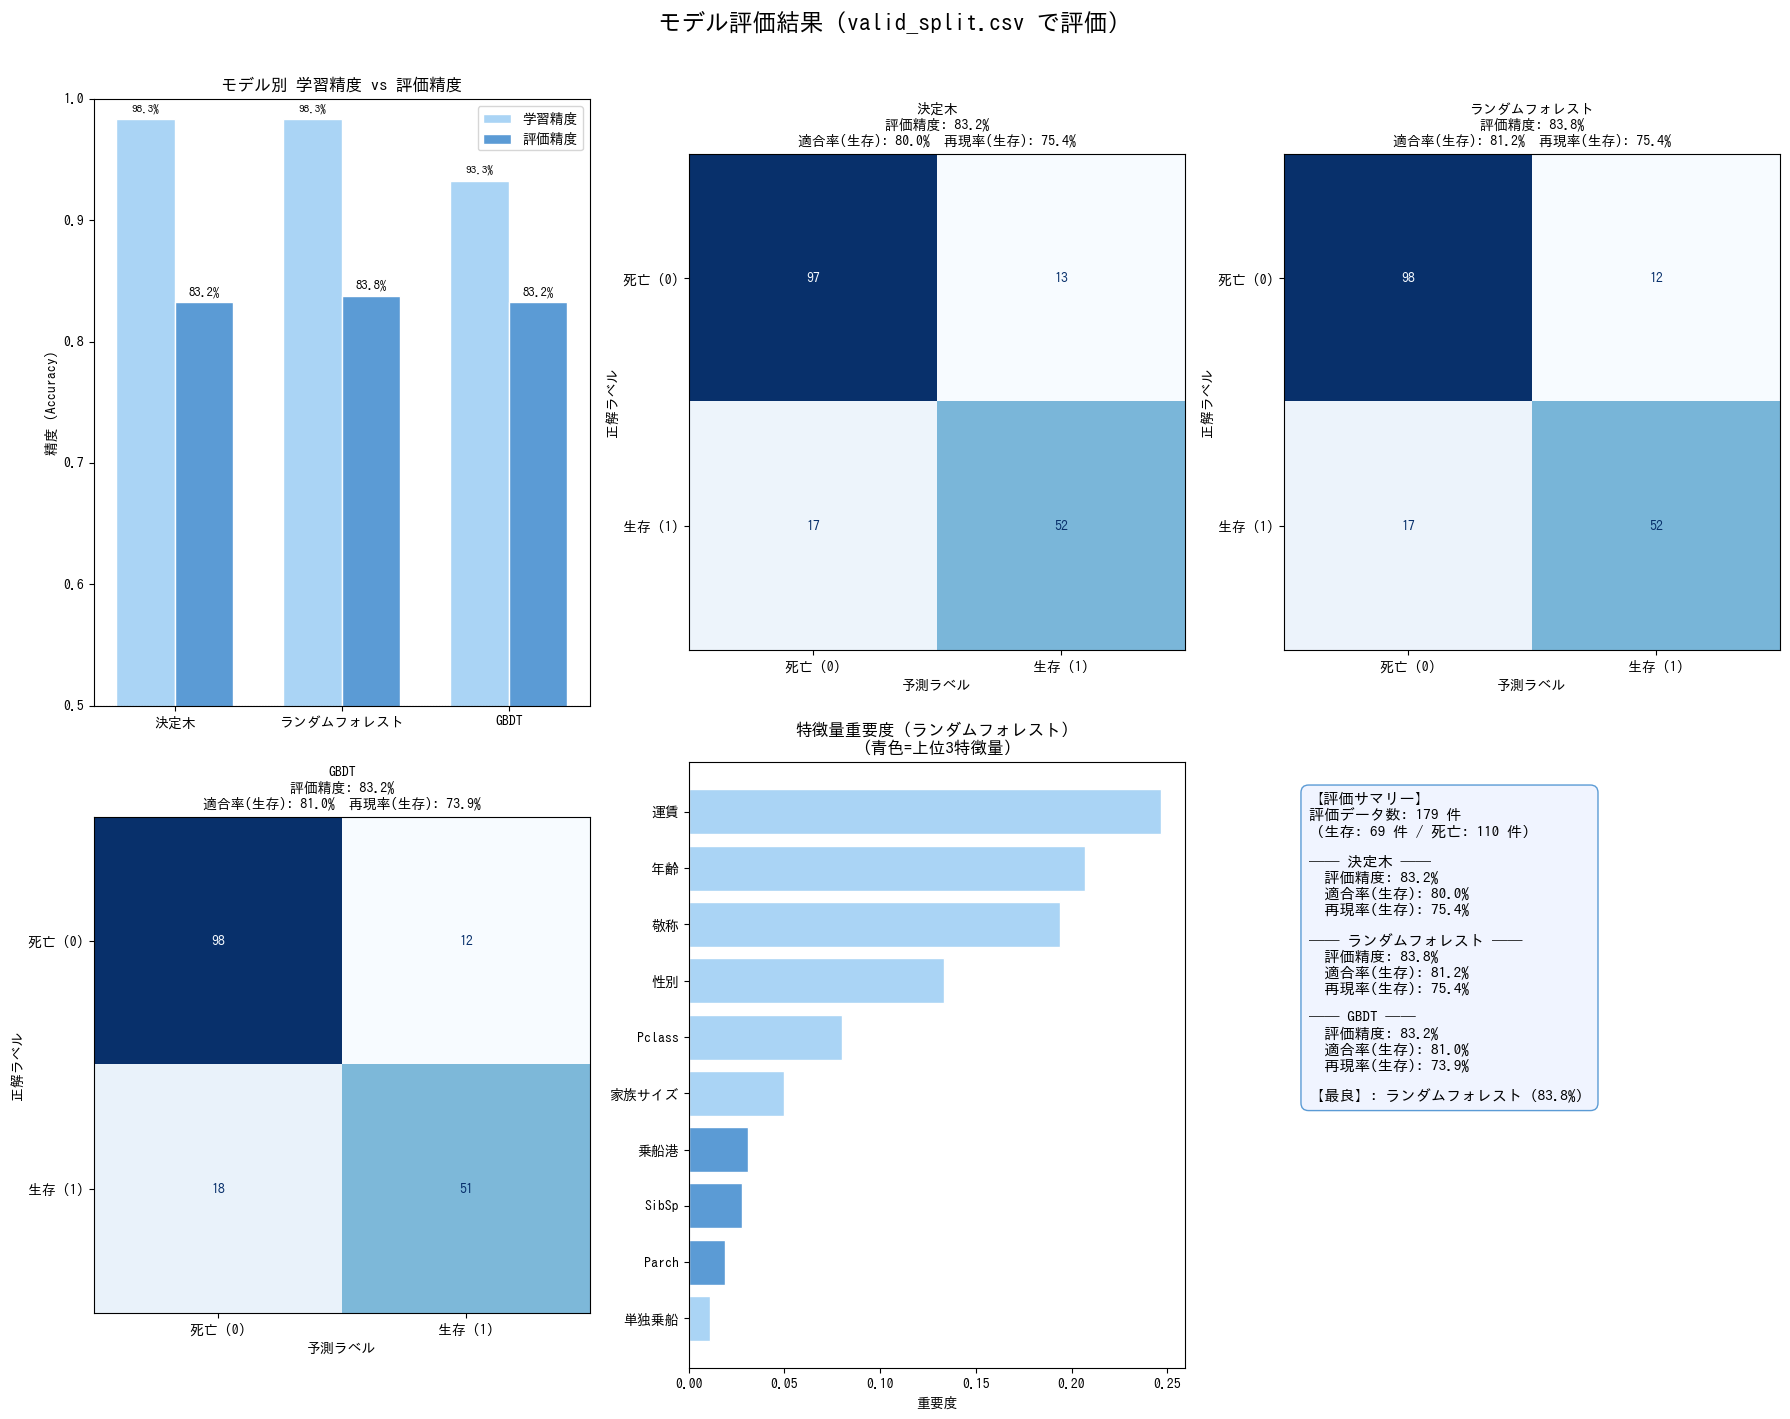

  最良モデル: ランダムフォレスト  評価精度 83.8%

【決定木】
              precision    recall  f1-score   support

          死亡      0.851     0.882     0.866       110
          生存      0.800     0.754     0.776        69

    accuracy                          0.832       179
   macro avg      0.825     0.818     0.821       179
weighted avg      0.831     0.832     0.831       179


【ランダムフォレスト】
              precision    recall  f1-score   support

          死亡      0.852     0.891     0.871       110
          生存      0.812     0.754     0.782        69

    accuracy                          0.838       179
   macro avg      0.832     0.822     0.827       179
weighted avg      0.837     0.838     0.837       179


【GBDT】
              precision    recall  f1-score   support

          死亡      0.845     0.891     0.867       110
          生存      0.810     0.739     0.773        69

    accuracy                          0.832       179
   macro avg      0.827     0.815     0.820       179
weighted avg   

In [14]:
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams['font.family'] = 'IPAGothic'
plt.rcParams['axes.unicode_minus'] = False

# ────────────────────────────────────────────────────────────
# STEP 4: 評価用データで結果を可視化（READMEの手順4）
# ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle('モデル評価結果（valid_split.csv で評価）', fontsize=17, fontweight='bold', y=1.01)

model_names = list(results.keys())
train_accs  = [results[k]['train_acc'] for k in model_names]
valid_accs  = [results[k]['valid_acc'] for k in model_names]

# ─── 1. 精度比較バーチャート ───────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
x   = np.arange(len(model_names))
w   = 0.35
bars_t = ax1.bar(x - w/2, train_accs, width=w, label='学習精度', color='#aad4f5', edgecolor='white')
bars_v = ax1.bar(x + w/2, valid_accs, width=w, label='評価精度', color='#5b9bd5', edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(model_names, fontsize=10)
ax1.set_ylim(0.5, 1.0)
ax1.set_ylabel('精度 (Accuracy)')
ax1.set_title('モデル別 学習精度 vs 評価精度', fontweight='bold')
ax1.axhline(0.5, color='grey', linestyle=':', linewidth=0.8)
ax1.legend()
for b, v in zip(bars_t, train_accs):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{v:.1%}', ha='center', fontsize=8)
for b, v in zip(bars_v, valid_accs):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{v:.1%}', ha='center', fontsize=9, fontweight='bold')

# ─── 2〜4. 各モデルの混同行列 ──────────────────────────────
for idx, (name, res) in enumerate(results.items()):
    ax = fig.add_subplot(2, 3, idx + 2)
    y_pred = res['model'].predict(X_valid)
    cm     = confusion_matrix(y_valid, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=['死亡 (0)', '生存 (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f'{name}\n'
        f'評価精度: {res["valid_acc"]:.1%}\n'
        f'適合率(生存): {tp/(tp+fp):.1%}  再現率(生存): {tp/(tp+fn):.1%}',
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('予測ラベル'); ax.set_ylabel('正解ラベル')

# ─── 5. 最良モデルの特徴量重要度 ──────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
feature_names = ['Pclass', '性別', '年齢', '運賃', '家族サイズ', '単独乗船',
                 '敬称', '乗船港', 'SibSp', 'Parch']
importances   = best_model.feature_importances_
sorted_idx    = np.argsort(importances)
colors_fi     = ['#5b9bd5' if i >= len(importances)-3 else '#aad4f5' for i in range(len(importances))]
ax5.barh([feature_names[i] for i in sorted_idx],
         importances[sorted_idx],
         color=[colors_fi[i] for i in sorted_idx], edgecolor='white')
ax5.set_title(f'特徴量重要度（{best_name}）\n（青色=上位3特徴量）', fontweight='bold')
ax5.set_xlabel('重要度')

# ─── 6. 評価サマリーテキスト ───────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
summary_lines = [
    '【評価サマリー】',
    f'評価データ数: {len(y_valid)} 件',
    f'（生存: {y_valid.sum()} 件 / 死亡: {(y_valid==0).sum()} 件）',
    '',
]
for name, res in results.items():
    y_pred = res['model'].predict(X_valid)
    cm     = confusion_matrix(y_valid, y_pred)
    tn, fp, fn, tp = cm.ravel()
    summary_lines += [
        f'── {name} ──',
        f'  評価精度: {res["valid_acc"]:.1%}',
        f'  適合率(生存): {tp/(tp+fp):.1%}',
        f'  再現率(生存): {tp/(tp+fn):.1%}',
        '',
    ]
summary_lines += [f'【最良】: {best_name}（{results[best_name]["valid_acc"]:.1%}）']
ax6.text(0.05, 0.95, '\n'.join(summary_lines),
         transform=ax6.transAxes, va='top', fontsize=11,
         fontfamily='IPAGothic',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f4ff', edgecolor='#5b9bd5'))

plt.tight_layout()
plt.savefig('../data/model_evaluation_result.png', dpi=120, bbox_inches='tight')
plt.show()

# テキスト出力
print("=" * 55)
print(f"  最良モデル: {best_name}  評価精度 {results[best_name]['valid_acc']:.1%}")
print("=" * 55)
for name, res in results.items():
    y_pred = res['model'].predict(X_valid)
    print(f"\n【{name}】")
    print(classification_report(y_valid, y_pred,
                                 target_names=['死亡', '生存'],
                                 digits=3))
print("グラフを data/model_evaluation_result.png に保存しました")


/tmp/ipykernel_682860/2912964930.py:205: UserWarning: Glyph 128674 (\N{SHIP}) missing from font(s) IPAGothic.
  plt.savefig('../data/deck_survival_analysis.png', dpi=130, bbox_inches='tight',


デッキ位置と生存率の図を data/deck_survival_analysis.png に保存しました


/home/shahin/Kaggle-Titnic-Machine-Learing-REPO/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128674 (\N{SHIP}) missing from font(s) IPAGothic.
  fig.canvas.print_figure(bytes_io, **kw)


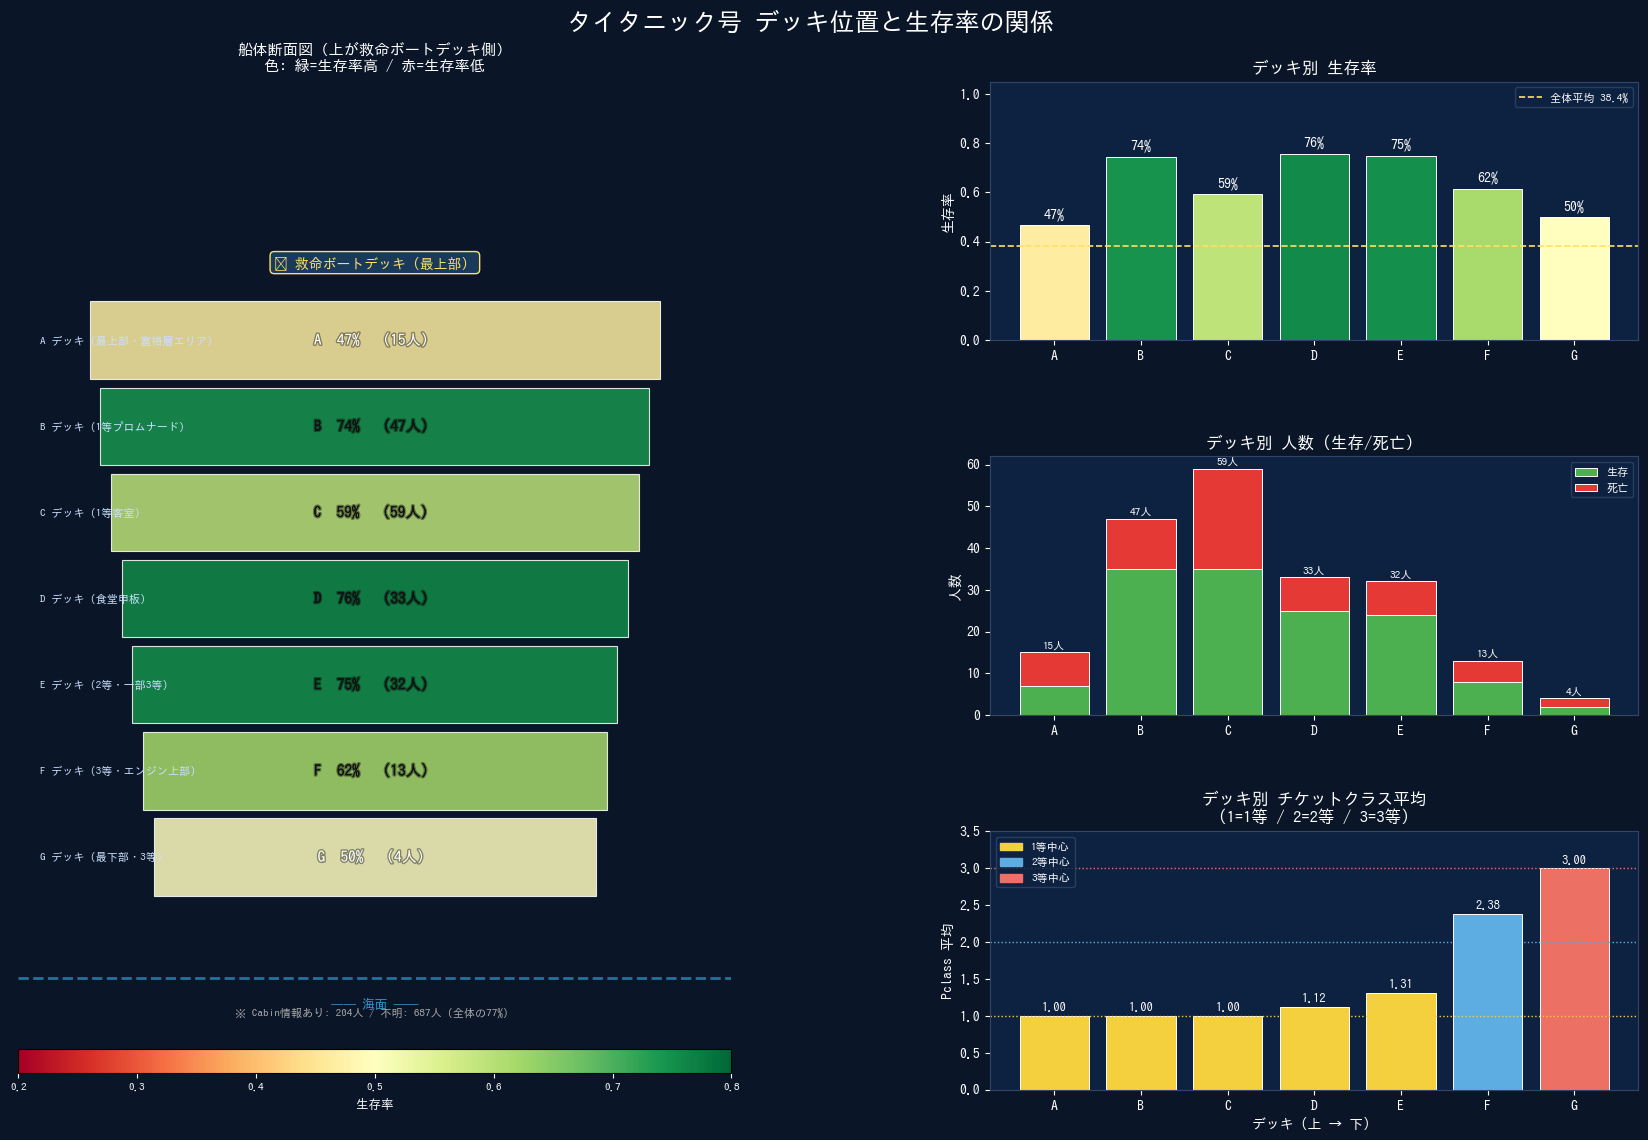

In [16]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import numpy as np

plt.rcParams['font.family'] = 'IPAGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── デッキ情報の抽出（Cabin列の先頭文字） ──────────────────────────────
df = raw.copy()
df['Deck'] = df['Cabin'].str[0]  # A/B/C/D/E/F/G/T or NaN

# デッキ順（船の上から下へ）
DECK_ORDER = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
# Cabin既知 / 不明 の件数
cabin_known = df['Deck'].notna().sum()
cabin_unknown = df['Deck'].isna().sum()

# デッキ別の生存率・人数・Pclass分布
deck_stats = (
    df[df['Deck'].isin(DECK_ORDER)]
    .groupby('Deck')
    .agg(
        total    = ('Survived', 'count'),
        survived = ('Survived', 'sum'),
        pclass_mean = ('Pclass', 'mean'),
    )
    .reindex(DECK_ORDER)
    .dropna()
)
deck_stats['rate'] = deck_stats['survived'] / deck_stats['total']

# ── 図のレイアウト ────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0a1628')
fig.suptitle('タイタニック号 デッキ位置と生存率の関係',
             fontsize=18, fontweight='bold', color='white', y=0.98)

# サブプロット定義: [左側の船体図 | 右側3グラフ縦並び]
gs = fig.add_gridspec(3, 2, width_ratios=[1.1, 1], hspace=0.45, wspace=0.38,
                      left=0.06, right=0.96, top=0.92, bottom=0.08)

ax_ship  = fig.add_subplot(gs[:, 0])   # 左: 船体断面図
ax_rate  = fig.add_subplot(gs[0, 1])   # 右上: 生存率バー
ax_cnt   = fig.add_subplot(gs[1, 1])   # 右中: 人数バー
ax_cls   = fig.add_subplot(gs[2, 1])   # 右下: Pclass平均

# ─────────────────────────────────────────────────────────────────────
# 1. 左パネル: 船体断面イメージ（デッキ別に色分け）
# ─────────────────────────────────────────────────────────────────────
ax_ship.set_facecolor('#0d2240')
ax_ship.set_xlim(0, 10)
ax_ship.set_ylim(-1.5, len(DECK_ORDER) + 2.5)
ax_ship.axis('off')

# デッキ名と色マップ（生存率で色変え、右グラフと統一）
rate_cmap = plt.cm.RdYlGn
norm_rate  = plt.Normalize(0.2, 0.8)

# 甲板（上部構造）
deck_labels_full = {
    'A': 'A デッキ（最上部・富裕層エリア）',
    'B': 'B デッキ（1等プロムナード）',
    'C': 'C デッキ（1等客室）',
    'D': 'D デッキ（食堂甲板）',
    'E': 'E デッキ（2等・一部3等）',
    'F': 'F デッキ（3等・エンジン上部）',
    'G': 'G デッキ（最下部・3等）',
}

# 船体外形（台形風）
hull_x = [1.0, 9.0, 8.5, 1.5, 1.0]
hull_y_bottom = -1.2
n_decks = len(DECK_ORDER)
deck_h = 1.0   # 各デッキの高さ

for i, d in enumerate(reversed(DECK_ORDER)):   # G→A（下から描く）
    y_idx = i                                   # 下=0, 上=n-1
    if d not in deck_stats.index:
        continue
    row = deck_stats.loc[d]
    color = rate_cmap(norm_rate(row['rate']))

    # デッキ区画（台形に近づくよう左右を少し傾ける）
    margin_l = 1.0 + (n_decks - 1 - i) * 0.15
    margin_r = 9.0 - (n_decks - 1 - i) * 0.15
    rect = plt.Polygon(
        [[margin_l, y_idx + 0.05],
         [margin_r, y_idx + 0.05],
         [margin_r, y_idx + deck_h - 0.05],
         [margin_l, y_idx + deck_h - 0.05]],
        closed=True, facecolor=color, edgecolor='white', linewidth=0.8, alpha=0.85
    )
    ax_ship.add_patch(rect)

    # デッキ名
    ax_ship.text(5.0, y_idx + deck_h / 2,
                 f'{d}  {row["rate"]:.0%}  （{int(row["total"])}人）',
                 ha='center', va='center', fontsize=11, fontweight='bold',
                 color='white' if row['rate'] < 0.55 else '#111',
                 path_effects=[pe.withStroke(linewidth=2, foreground='#00000066')])

    # 左にデッキ説明ラベル
    ax_ship.text(0.3, y_idx + deck_h / 2,
                 deck_labels_full[d],
                 ha='left', va='center', fontsize=8, color='#cce0ff')

# 救命ボート（最上部）
ax_ship.text(5.0, n_decks + 0.4, '🚢 救命ボートデッキ（最上部）',
             ha='center', va='center', fontsize=10, color='#ffe066',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a3a5c', edgecolor='#ffe066'))

# 海面ライン
ax_ship.axhline(hull_y_bottom + 0.3, color='#3399cc', linewidth=2, linestyle='--', alpha=0.7)
ax_ship.text(5.0, hull_y_bottom + 0.0, '── 海面 ──',
             ha='center', va='center', fontsize=9, color='#3399cc')

# Cabinデータ欠損の注記
ax_ship.text(5.0, -1.3,
             f'※ Cabin情報あり: {cabin_known}人 / 不明: {cabin_unknown}人（全体の{cabin_unknown/891:.0%}）',
             ha='center', va='center', fontsize=8, color='#aaaaaa',
             style='italic')

ax_ship.set_title('船体断面図（上が救命ボートデッキ側）\n色: 緑=生存率高 / 赤=生存率低',
                  fontsize=11, color='white', pad=8)

# カラーバー（左パネル用）
sm = plt.cm.ScalarMappable(cmap=rate_cmap, norm=norm_rate)
cbar = fig.colorbar(sm, ax=ax_ship, orientation='horizontal',
                    fraction=0.04, pad=0.02, aspect=30)
cbar.set_label('生存率', color='white', fontsize=9)
cbar.ax.xaxis.set_tick_params(color='white')
plt.setp(cbar.ax.xaxis.get_ticklabels(), color='white', fontsize=8)
cbar.ax.set_facecolor('#0d2240')

# ─────────────────────────────────────────────────────────────────────
# 2. 右上: デッキ別 生存率バーチャート
# ─────────────────────────────────────────────────────────────────────
ax_rate.set_facecolor('#0d2240')
decks_in = deck_stats.index.tolist()
rates    = deck_stats['rate'].values
colors_d = [rate_cmap(norm_rate(r)) for r in rates]

bars = ax_rate.bar(decks_in, rates, color=colors_d, edgecolor='white', linewidth=0.7)
ax_rate.axhline(0.384, color='#ffe066', linestyle='--', linewidth=1.2, label=f'全体平均 38.4%')
for b, r in zip(bars, rates):
    ax_rate.text(b.get_x() + b.get_width()/2, b.get_height() + 0.015,
                 f'{r:.0%}', ha='center', va='bottom', fontsize=10,
                 color='white', fontweight='bold')
ax_rate.set_ylim(0, 1.05)
ax_rate.set_ylabel('生存率', color='white')
ax_rate.set_title('デッキ別 生存率', color='white', fontweight='bold')
ax_rate.tick_params(colors='white')
ax_rate.spines[:].set_color('#334466')
ax_rate.yaxis.label.set_color('white')
ax_rate.legend(fontsize=8, facecolor='#0d2240', labelcolor='white', edgecolor='#334466')
ax_rate.set_facecolor('#0d2240')
for s in ax_rate.spines.values(): s.set_color('#334466')

# ─────────────────────────────────────────────────────────────────────
# 3. 右中: デッキ別 人数（生存/死亡 積み上げ）
# ─────────────────────────────────────────────────────────────────────
ax_cnt.set_facecolor('#0d2240')
survived_cnt = deck_stats['survived'].values.astype(int)
died_cnt     = (deck_stats['total'] - deck_stats['survived']).values.astype(int)

b1 = ax_cnt.bar(decks_in, survived_cnt, label='生存', color='#4caf50', edgecolor='white', lw=0.7)
b2 = ax_cnt.bar(decks_in, died_cnt, bottom=survived_cnt, label='死亡',
                color='#e53935', edgecolor='white', lw=0.7)
for x_pos, (sv, di) in enumerate(zip(survived_cnt, died_cnt)):
    ax_cnt.text(x_pos, sv + di + 0.5, f'{sv+di}人', ha='center', va='bottom',
                fontsize=8, color='white')
ax_cnt.set_ylabel('人数', color='white')
ax_cnt.set_title('デッキ別 人数（生存/死亡）', color='white', fontweight='bold')
ax_cnt.tick_params(colors='white')
ax_cnt.legend(fontsize=8, facecolor='#0d2240', labelcolor='white', edgecolor='#334466')
for s in ax_cnt.spines.values(): s.set_color('#334466')

# ─────────────────────────────────────────────────────────────────────
# 4. 右下: デッキ別 Pclass平均（上位デッキ = 1等が多い）
# ─────────────────────────────────────────────────────────────────────
ax_cls.set_facecolor('#0d2240')
pclass_means = deck_stats['pclass_mean'].values
cls_colors   = ['#f4d03f' if v < 1.5 else '#5dade2' if v < 2.5 else '#ec7063'
                for v in pclass_means]
bars3 = ax_cls.bar(decks_in, pclass_means, color=cls_colors, edgecolor='white', lw=0.7)
ax_cls.axhline(1.0, color='#f4d03f', linestyle=':', linewidth=1)
ax_cls.axhline(2.0, color='#5dade2', linestyle=':', linewidth=1)
ax_cls.axhline(3.0, color='#ec7063', linestyle=':', linewidth=1)
for b, v in zip(bars3, pclass_means):
    ax_cls.text(b.get_x() + b.get_width()/2, b.get_height() + 0.04,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9, color='white')
ax_cls.set_ylim(0, 3.5)
ax_cls.set_ylabel('Pclass 平均', color='white')
ax_cls.set_xlabel('デッキ（上 → 下）', color='white')
ax_cls.set_title('デッキ別 チケットクラス平均\n（1=1等 / 2=2等 / 3=3等）', color='white', fontweight='bold')
ax_cls.tick_params(colors='white')
legend_cls = [mpatches.Patch(color='#f4d03f', label='1等中心'),
              mpatches.Patch(color='#5dade2', label='2等中心'),
              mpatches.Patch(color='#ec7063', label='3等中心')]
ax_cls.legend(handles=legend_cls, fontsize=8, facecolor='#0d2240',
              labelcolor='white', edgecolor='#334466')
for s in ax_cls.spines.values(): s.set_color('#334466')

plt.savefig('../data/deck_survival_analysis.png', dpi=130, bbox_inches='tight',
            facecolor=fig.get_facecolor())
print('デッキ位置と生存率の図を data/deck_survival_analysis.png に保存しました')
plt.show()
